# WRP Simulation: Lodewijkstraat (Statistical Verification)

This notebook runs the Lodewijkstraat simulation with **Empirical Gamma Distributions** extracted from the client's Excel data. It executes multiple Monte Carlo replications (N=30) to compute robust 95% Confidence Intervals for system performance.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Entity import CustomerItineraryGenerator
from DSE import (
    Environment, LocationType, QueueLocation, 
    ServiceLocation, VehicleSize, Location, ItineraryItem
)

# Apply seaborn theme for clean visualizations
sns.set_theme(style="whitegrid")

### 1. Define Realistic Samplers (From Data Lodewijkstraat.xlsx)

In [2]:
class Sampler:
    def __init__(self, name, params, seed=None):
        self.rng = np.random.default_rng(seed)
        self._sampling_method = getattr(self.rng, name)
        self.dist_params = params

    def sample(self, size=None):
        val = self._sampling_method(**self.dist_params, size=size)
        return max(0.1, abs(float(np.squeeze(val))))

def get_gamma_params(mean, stdev):
    variance = stdev ** 2
    shape = (mean ** 2) / variance
    scale = variance / mean
    return {"shape": shape, "scale": scale}

# Data extracted from "Data Lodewijkstraat.xlsx"
samplers = {
    'entrance': Sampler('gamma', get_gamma_params(30, 12)),
    'hall_big': Sampler('gamma', get_gamma_params(423, 270)),
    'hall_small': Sampler('gamma', get_gamma_params(240, 150)),
    'overflow_small': Sampler('gamma', get_gamma_params(180, 150)),
    'dcdd': Sampler('gamma', get_gamma_params(331, 300)),
    'green': Sampler('gamma', get_gamma_params(341, 260)),
    'rest': Sampler('gamma', get_gamma_params(141, 36))
}

In [3]:
def generate_scheduled_customers(scale=1.0):
    generator = CustomerItineraryGenerator()
    dse_customers = []
    
    location_map = {
        0: LocationType.MAIN_QUEUE, 
        1: LocationType.HALL_OVERFLOW, 
        2: LocationType.DCDD, 
        3: LocationType.GREEN,
        4: LocationType.REST, 
        5: LocationType.EXIT
    }

    # Defined schedule: (start_sec, end_sec, rate_per_hour)
    # 0 sec = 09:30 AM
    schedule = [
        (0,      1800,  10 * scale),
        (1800,   4500,  100 * scale),
        (4500,   7200,  40 * scale),
        (7200,   12600, 100 * scale),
        (12600,  19800, 100 * scale),
        (19800,  25200, 80 * scale),
        (25200,  27000, 50 * scale)
    ]
    
    arrival_clock = 0.0
    rng = np.random.default_rng()
    
    for start_time, end_time, rate_per_hour in schedule:
        if rate_per_hour <= 0: continue
        rate_per_sec = rate_per_hour / 3600.0
        
        if arrival_clock < start_time:
            arrival_clock = start_time
            
        while True:
            inter_arrival = rng.exponential(1.0 / rate_per_sec)
            arrival_clock += inter_arrival
            
            if arrival_clock >= end_time:
                # Rewind clock slightly to boundary so next bucket properly captures overflow
                arrival_clock -= inter_arrival
                break
                
            raw_itinerary = generator.Next()
            v_size = VehicleSize.BIG if np.random.rand() < 0.47 else VehicleSize.SMALL
            
            dse_itinerary = []
            for i, loc_int in enumerate(raw_itinerary):
                loc_enum = location_map[loc_int]
                
                service_time = 0.0
                if loc_enum == LocationType.HALL_OVERFLOW:
                    service_time = samplers['hall_big'].sample() if v_size == VehicleSize.BIG else samplers['hall_small'].sample()
                elif loc_enum == LocationType.DCDD:
                    service_time = samplers['dcdd'].sample()
                elif loc_enum == LocationType.GREEN:
                    service_time = samplers['green'].sample()
                elif loc_enum == LocationType.REST:
                    service_time = samplers['rest'].sample()
                    
                item = ItineraryItem(location=loc_enum, service_time=service_time)
                if i == 0:
                    item.start_time = arrival_clock
                dse_itinerary.append(item)
                if i == 0:
                    dse_itinerary.append(ItineraryItem(location=LocationType.HALL_QUEUE, service_time=0))
                    
            import DSE 
            dse_customers.append(DSE.Customer(dse_itinerary, v_size))
            
    return dse_customers


### 2. Network Configuration
Connecting nodes ensuring prioritisation according to business rules.

In [4]:
def setup_environment(customers):
    entrance = QueueLocation(LocationType.MAIN_QUEUE, maximum_capacity=99999)
    hall_queue = QueueLocation(LocationType.HALL_QUEUE, maximum_capacity=14)
    
    hall_pairs = [[i, i+1] for i in range(0, 12, 2)]
    hall_overflow = ServiceLocation(LocationType.HALL_OVERFLOW, max_capacity=22, single_bays=22, single_bay_pairs=hall_pairs)
    
    dcdd_pairs = [[0, 1], [2, 3], [4, 5]]
    dcdd = ServiceLocation(LocationType.DCDD, max_capacity=7, single_bays=7, single_bay_pairs=dcdd_pairs)
    
    green_pairs = [[0, 1], [1, 2], [2, 3], [3, 4]]
    green = ServiceLocation(LocationType.GREEN, max_capacity=5, single_bays=5, single_bay_pairs=green_pairs)
    
    rest_pairs = [[0, 1], [1, 2], [2, 3], [3, 4]]
    rest = ServiceLocation(LocationType.REST, max_capacity=5, single_bays=5, single_bay_pairs=rest_pairs)
    
    exit_node = QueueLocation(LocationType.EXIT, maximum_capacity=999999)

    entrance.connect(hall_queue)
    hall_queue.connect(hall_overflow)
    hall_queue.connect(dcdd)
    hall_queue.connect(green)
    hall_queue.connect(rest)
    hall_queue.connect(exit_node)

    dcdd.connect(rest)
    green.connect(rest)
    hall_overflow.connect(rest)
    
    hall_overflow.connect(dcdd)
    
    hall_overflow.connect(exit_node)
    dcdd.connect(exit_node)
    green.connect(exit_node)
    rest.connect(exit_node)

    locations_dict = {
        LocationType.MAIN_QUEUE: entrance,
        LocationType.HALL_QUEUE: hall_queue,
        LocationType.HALL_OVERFLOW: hall_overflow,
        LocationType.DCDD: dcdd,
        LocationType.GREEN: green,
        LocationType.REST: rest,
        LocationType.EXIT: exit_node
    }
    
    return Environment(customers, locations_dict, initial_time=0)

### 3. Simulation Replications (Statistical Batches)
Generating N=30 runs for both Baseline and +20% scenario to get full statistical convergence.

In [5]:
def run_replications(scale=1.0, num_replications=30):
    all_traces = []
    all_turnarounds = []
    
    for rep in range(num_replications):
        customers = generate_scheduled_customers(scale)
        env = setup_environment(customers)
        
        # Run up to 35000s (~9.7 hours) to ensure all customers finish
        env.run(end_time=35000)
        
        data = []
        for i, c in enumerate(customers):
            cid = getattr(c, 'id', i) 
            for item in c.itinerary:
                data.append({
                    'replication': rep,
                    'customer_id': cid,
                    'vehicle_size': c.vehicle_size.name,
                    'location': item.location.name,
                    'start_time': item.start_time,
                    'end_time': item.end_time,
                    'wait_time': item.time_waiting,
                    'service_time': item.service_time
                })
                
        df_rep = pd.DataFrame(data)
        df_rep['queue_exit_time'] = df_rep['start_time'] + df_rep['wait_time']
        all_traces.append(df_rep)
        
        sys_time = df_rep.groupby('customer_id').agg(
            entry_time=('start_time', 'min'),
            exit_time=('end_time', 'max')
        )
        sys_time['total_time'] = sys_time['exit_time'] - sys_time['entry_time']
        sys_time['replication'] = rep
        all_turnarounds.append(sys_time)
        
    return pd.concat(all_traces, ignore_index=True), pd.concat(all_turnarounds, ignore_index=True)

print("Running 100 Monte Carlo Replications for Baseline Scheduled Arrivals...")
df_base, turn_base = run_replications(scale=1.0, num_replications=100)
print("Finished Baseline.")
print("\nRunning 100 Monte Carlo Replications for +20% Scenario Scheduled Arrivals...")
df_inc, turn_inc = run_replications(scale=1.2, num_replications=100)
print("Finished +20% Scenario.")


Running 100 Monte Carlo Replications for Baseline Scheduled Arrivals...
Finished Baseline.

Running 100 Monte Carlo Replications for +20% Scenario Scheduled Arrivals...
Finished +20% Scenario.


### 4. Visualizations & Validations (With 95% Confidence Intervals)

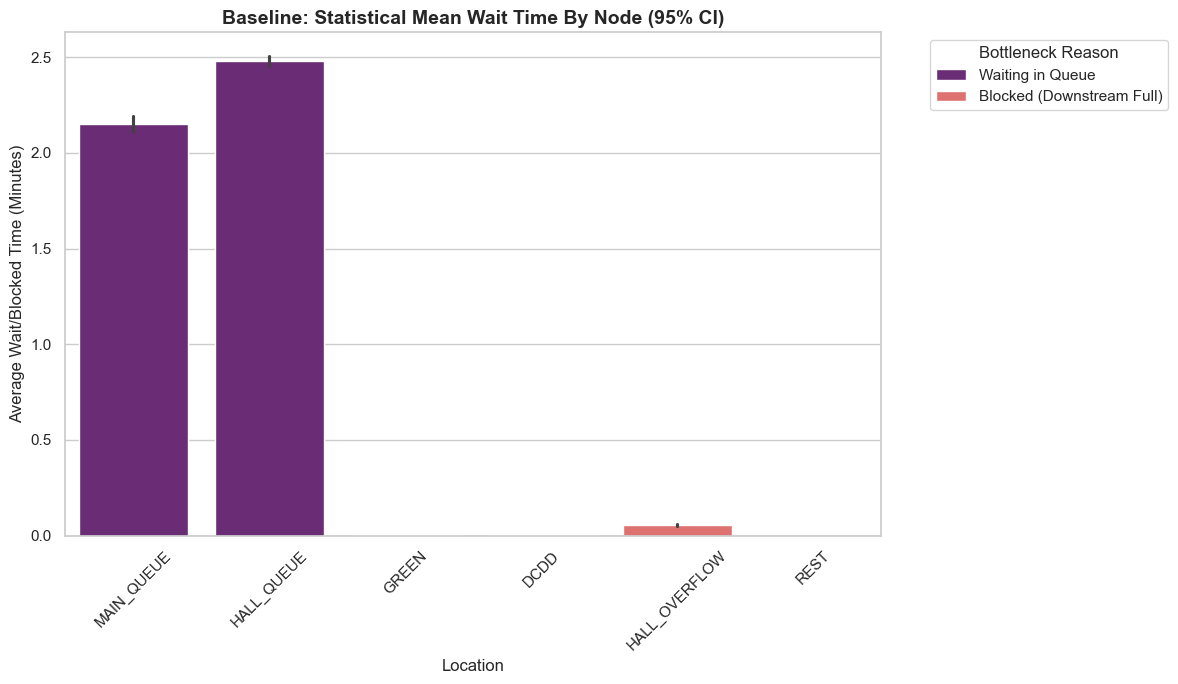

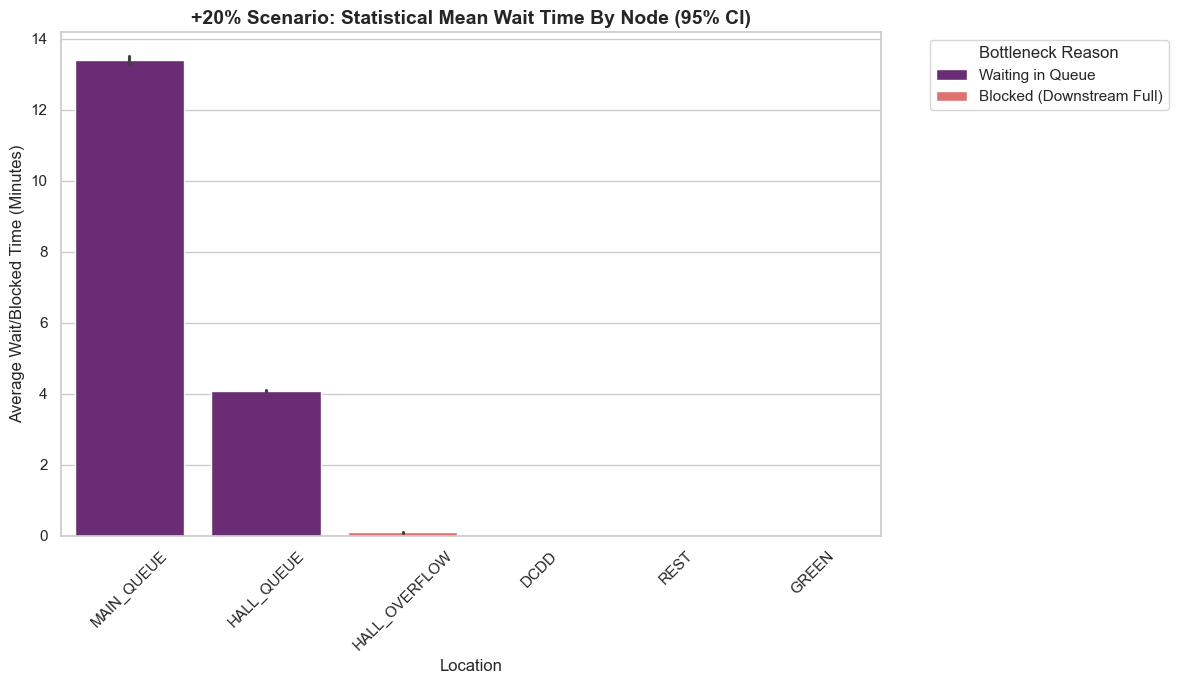

In [6]:
def plot_statistical_wait_times(df, title):
    df_filtered = df[df['location'] != 'EXIT'].copy()
    # Convert seconds to minutes for easier readability
    df_filtered['Wait Time (Mins)'] = df_filtered['wait_time'] / 60.0
    df_filtered['Wait Type'] = df_filtered['service_time'].apply(
        lambda x: 'Waiting in Queue' if x == 0 else 'Blocked (Downstream Full)'
    )
    
    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=df_filtered, 
        x='location', 
        y='Wait Time (Mins)', 
        hue='Wait Type', 
        dodge=False, 
        palette='magma',
        errorbar=('ci', 95)
    )
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Average Wait/Blocked Time (Minutes)', fontsize=12)
    plt.xlabel('Location', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Bottleneck Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_statistical_wait_times(df_base, 'Baseline: Statistical Mean Wait Time By Node (95% CI)')
plot_statistical_wait_times(df_inc, '+20% Scenario: Statistical Mean Wait Time By Node (95% CI)')

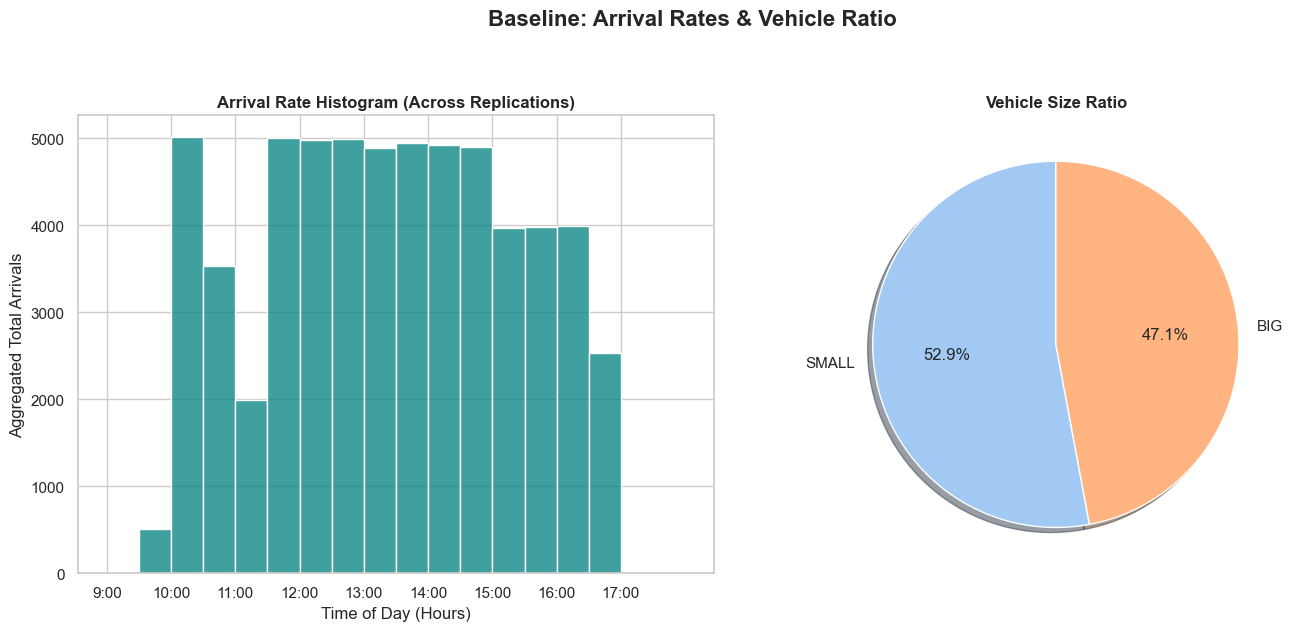

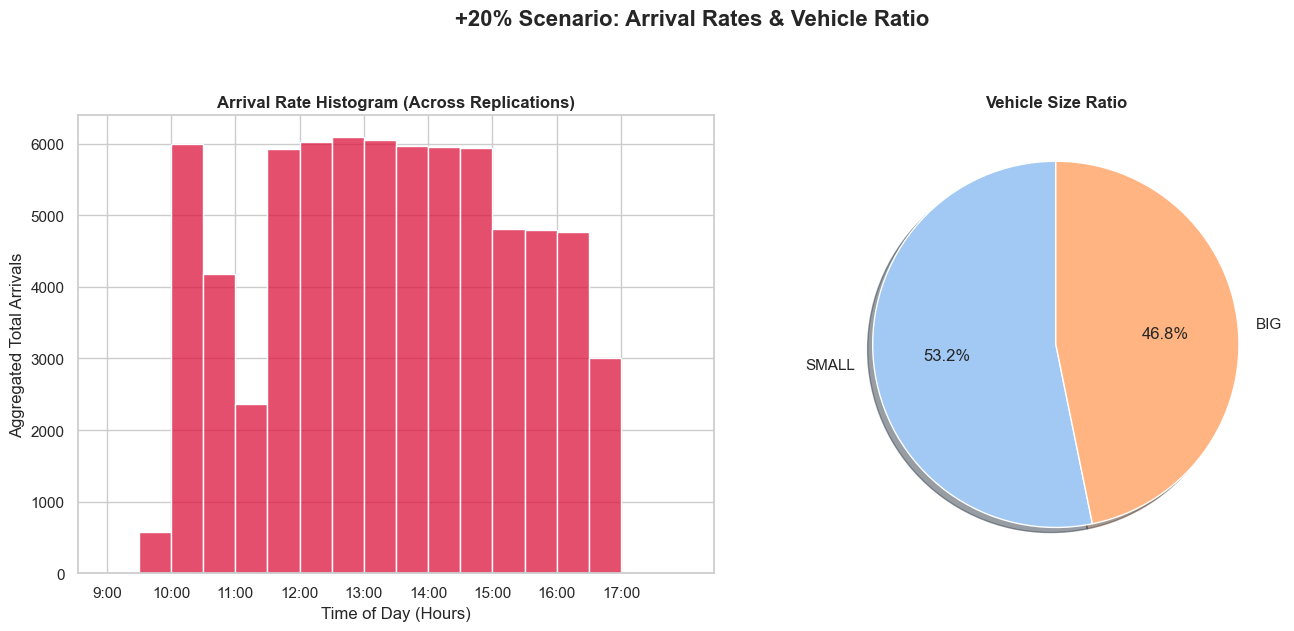

In [7]:
def plot_arrival_and_vehicles(df, title, color='skyblue'):
    # Filter for first arrival node to calculate accurate simulation entrance times
    arrivals = df[df['location'] == 'MAIN_QUEUE'].copy()
    arrivals['Time of Day (Hours)'] = 9.5 + (arrivals['start_time'] / 3600.0)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Arrival Distribution (Explicit 1D bins to completely bypass the internal broadcast error)
    explicit_bins = np.arange(9.0, 18.5, 0.5)
    sns.histplot(data=arrivals, x='Time of Day (Hours)', bins=explicit_bins, ax=axes[0], color=color)
    axes[0].set_title('Arrival Rate Histogram (Across Replications)', fontweight='bold')
    axes[0].set_ylabel('Aggregated Total Arrivals')
    axes[0].set_xticks(np.arange(9, 18, 1))
    axes[0].set_xticklabels([f"{int(h)}:00" if h % 1 == 0 else f"{int(h)}:30" for h in np.arange(9, 18, 1)])
    
    # 2. Vehicle Ratio Pie Chart
    counts = arrivals['vehicle_size'].value_counts()
    axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), shadow=True, startangle=90)
    axes[1].set_title('Vehicle Size Ratio', fontweight='bold')
    
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

plot_arrival_and_vehicles(df_base, 'Baseline: Arrival Rates & Vehicle Ratio', color='teal')
plot_arrival_and_vehicles(df_inc, '+20% Scenario: Arrival Rates & Vehicle Ratio', color='crimson')

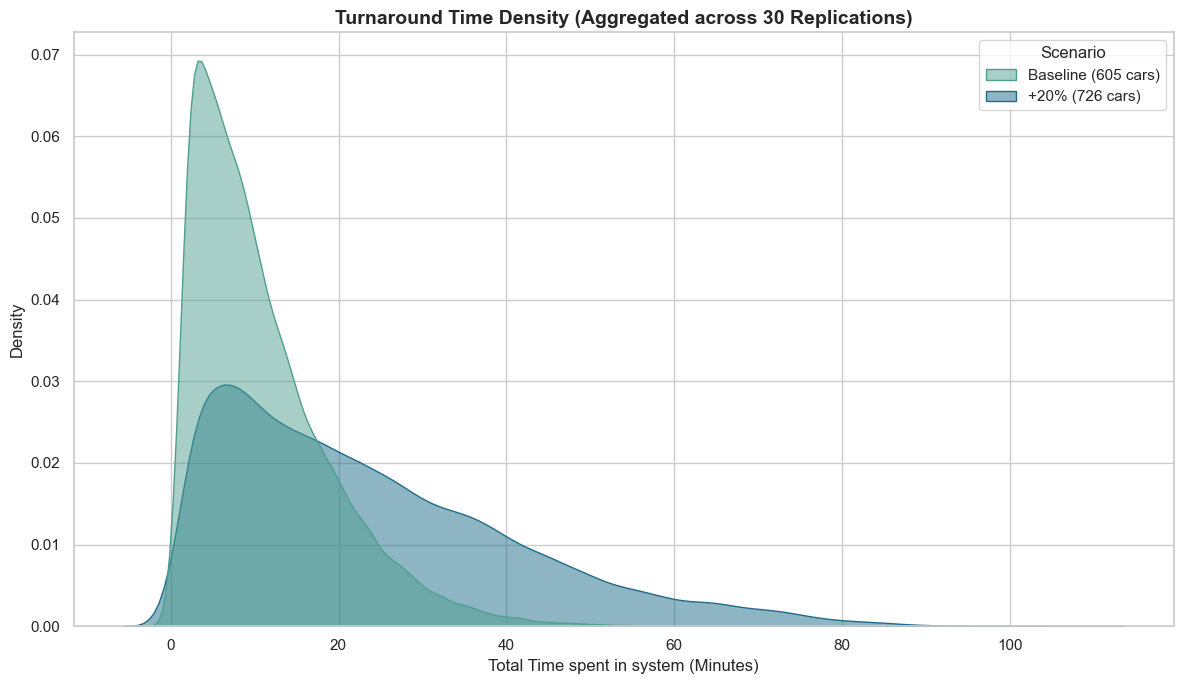

In [8]:
def plot_turnaround_times_kde(turn_base, turn_inc):
    plt.figure(figsize=(12, 7))
    
    # Convert Turnaround Time to Minutes
    turn_base = turn_base.copy()
    turn_inc = turn_inc.copy()
    turn_base['total_time_mins'] = turn_base['total_time'] / 60.0
    turn_inc['total_time_mins'] = turn_inc['total_time'] / 60.0
    
    turn_base['Scenario'] = 'Baseline (605 cars)'
    turn_inc['Scenario'] = '+20% (726 cars)'
    
    combined = pd.concat([turn_base, turn_inc])
    
    sns.kdeplot(data=combined, x='total_time_mins', hue='Scenario', fill=True, common_norm=False, palette='crest', alpha=0.5)
    
    plt.title("Turnaround Time Density (Aggregated across 30 Replications)", fontsize=14, fontweight='bold')
    plt.xlabel('Total Time spent in system (Minutes)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_turnaround_times_kde(turn_base, turn_inc)

Building Line plots (this takes a few seconds)...


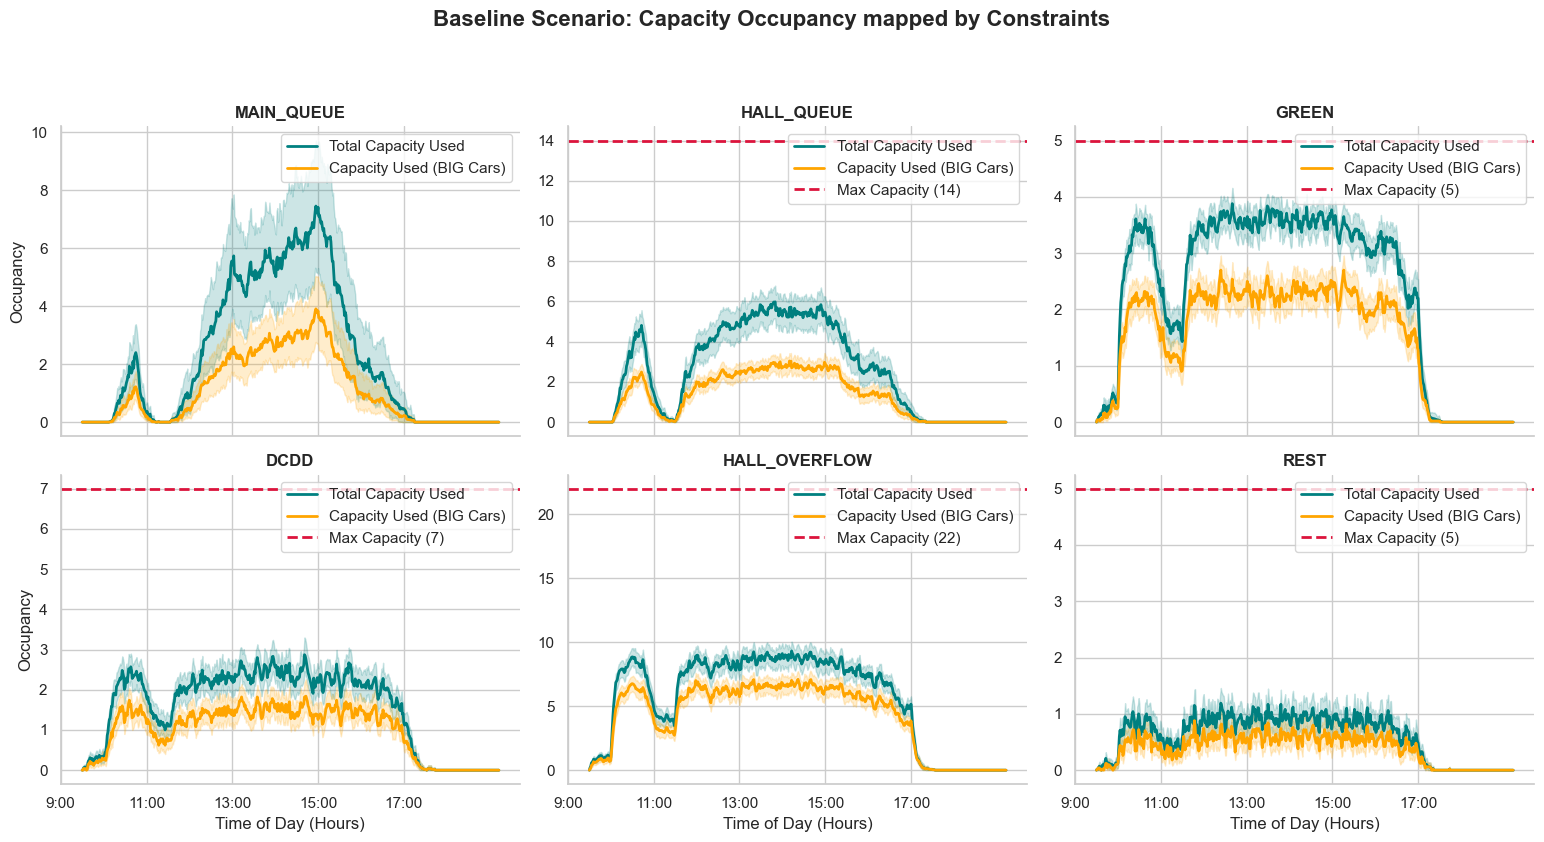

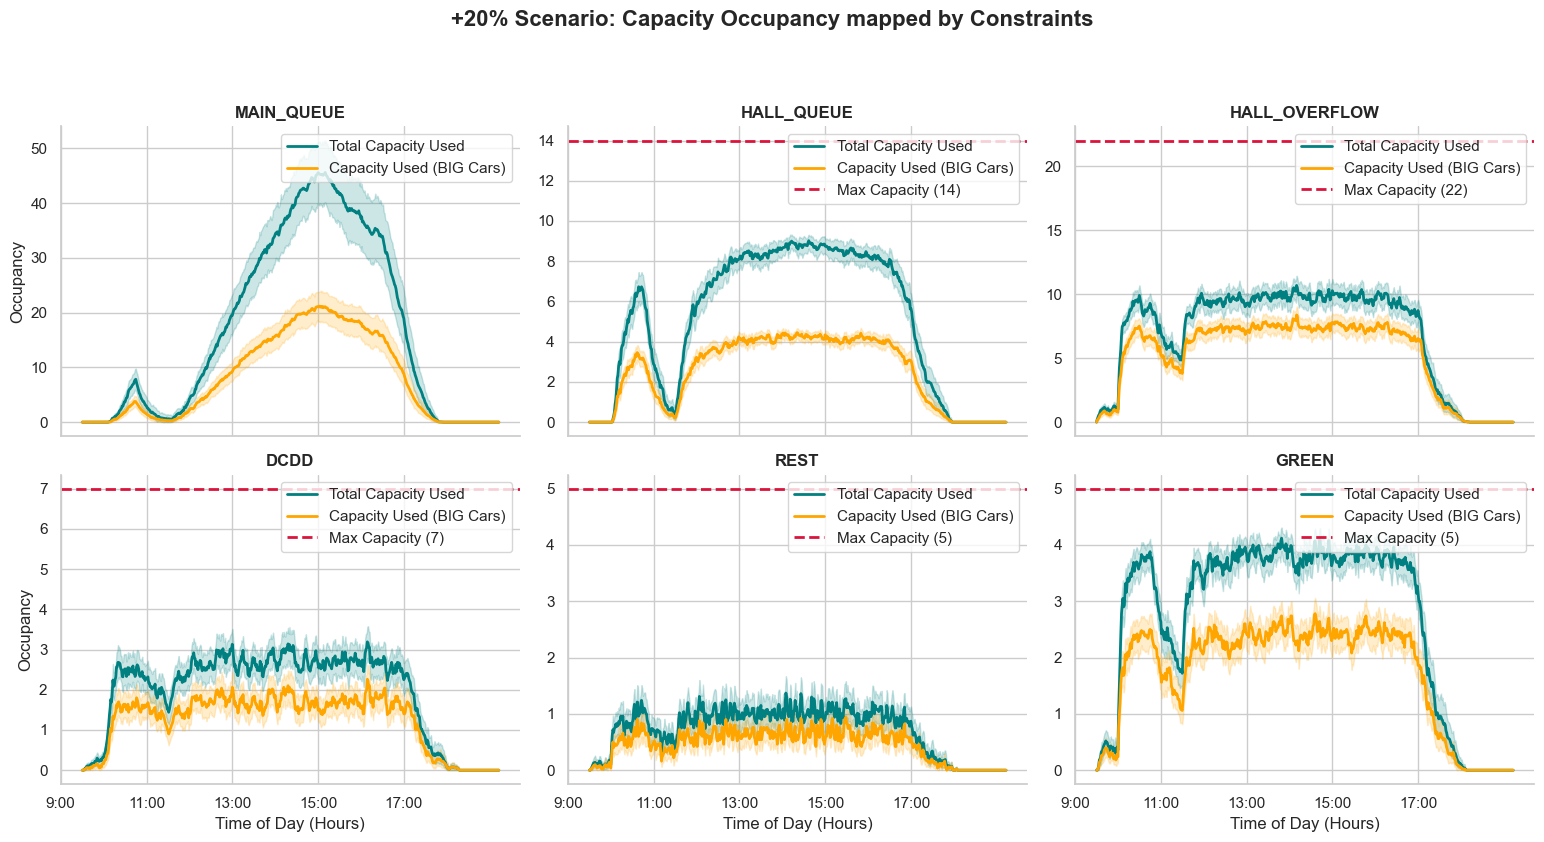

In [9]:
def plot_queue_progress_ci(df, title):
    time_bins = np.arange(0, 35000, 60)
    time_hours = 9.5 + (time_bins / 3600.0) 
    
    locations = [loc for loc in df['location'].unique() if loc != 'EXIT']
    records = []
    
    for rep in df['replication'].unique():
        rep_df = df[df['replication'] == rep]
        for loc in locations:
            loc_df = rep_df[(rep_df['location'] == loc) & (rep_df['start_time'] < rep_df['end_time'])]
            small_df = loc_df[loc_df['vehicle_size'] == 'SMALL']
            big_df = loc_df[loc_df['vehicle_size'] == 'BIG']
            
            b_weight = 2 if loc not in ['MAIN_QUEUE', 'HALL_QUEUE'] else 1
            
            s_occ = np.zeros(len(time_bins))
            if not small_df.empty:
                s_arr = pd.DataFrame({'time': small_df['start_time'], 'change': 1})
                s_dep = pd.DataFrame({'time': small_df['end_time'], 'change': -1})
                s_ev = pd.concat([s_arr, s_dep]).sort_values(by=['time', 'change'], ascending=[True, False])
                s_ev['occupancy'] = s_ev['change'].cumsum()
                s_idxs = np.searchsorted(s_ev['time'].values, time_bins, side='right') - 1
                s_occ = np.where(s_idxs >= 0, s_ev['occupancy'].values[s_idxs], 0)
                
            b_occ = np.zeros(len(time_bins))
            if not big_df.empty:
                b_arr = pd.DataFrame({'time': big_df['start_time'], 'change': b_weight})
                b_dep = pd.DataFrame({'time': big_df['end_time'], 'change': -b_weight})
                b_ev = pd.concat([b_arr, b_dep]).sort_values(by=['time', 'change'], ascending=[True, False])
                b_ev['occupancy'] = b_ev['change'].cumsum()
                b_idxs = np.searchsorted(b_ev['time'].values, time_bins, side='right') - 1
                b_occ = np.where(b_idxs >= 0, b_ev['occupancy'].values[b_idxs], 0)
                
            tot_occ = s_occ + b_occ
            
            temp_tot = pd.DataFrame({'Time of Day (Hours)': time_hours, 'Occupancy': tot_occ, 'Type': 'Total Capacity Used'})
            temp_tot['location'] = loc
            temp_tot['replication'] = rep
            records.append(temp_tot)
            
            temp_big = pd.DataFrame({'Time of Day (Hours)': time_hours, 'Occupancy': b_occ, 'Type': 'Capacity Used (BIG Cars)'})
            temp_big['location'] = loc
            temp_big['replication'] = rep
            records.append(temp_big)
            
    progress_df = pd.concat(records, ignore_index=True)
    
    max_cap = {
        'MAIN_QUEUE': None,
        'HALL_QUEUE': 14,
        'HALL_OVERFLOW': 22,
        'DCDD': 7,
        'GREEN': 5,
        'REST': 5
    }
    
    g = sns.FacetGrid(progress_df, col="location", col_wrap=3, height=4, aspect=1.3, sharey=False)
    g.map_dataframe(sns.lineplot, x='Time of Day (Hours)', y='Occupancy', hue='Type', errorbar=('ci', 95), linewidth=2, palette=['teal', 'orange'])
    
    for ax, loc_name in zip(g.axes.flatten(), g.col_names):
        cap = max_cap.get(loc_name)
        if cap is not None:
            ax.axhline(cap, color='crimson', linestyle='--', linewidth=2, label=f'Max Capacity ({cap})')
        ax.legend(loc='upper right')
        ax.set_title(loc_name, fontweight='bold')
        ax.set_xticks(np.arange(9, 19, 2))
        ax.set_xticklabels([f"{int(h)}:00" if h % 1 == 0 else f"{int(h)}:30" for h in np.arange(9, 19, 2)])
        
    g.fig.suptitle(title, y=1.05, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Building Line plots (this takes a few seconds)...")
plot_queue_progress_ci(df_base, 'Baseline Scenario: Capacity Occupancy mapped by Constraints')
plot_queue_progress_ci(df_inc, '+20% Scenario: Capacity Occupancy mapped by Constraints')